In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\edwin\\OneDrive\\Desktop\\development_journey\\20.Machine Learning\\diabetic _case_study\\Untitled.xls")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
df.shape

(768, 9)

In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [9]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [10]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [11]:
Y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [12]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [13]:
Y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train))
X_test =  pd.DataFrame(scaler.transform(X_test))

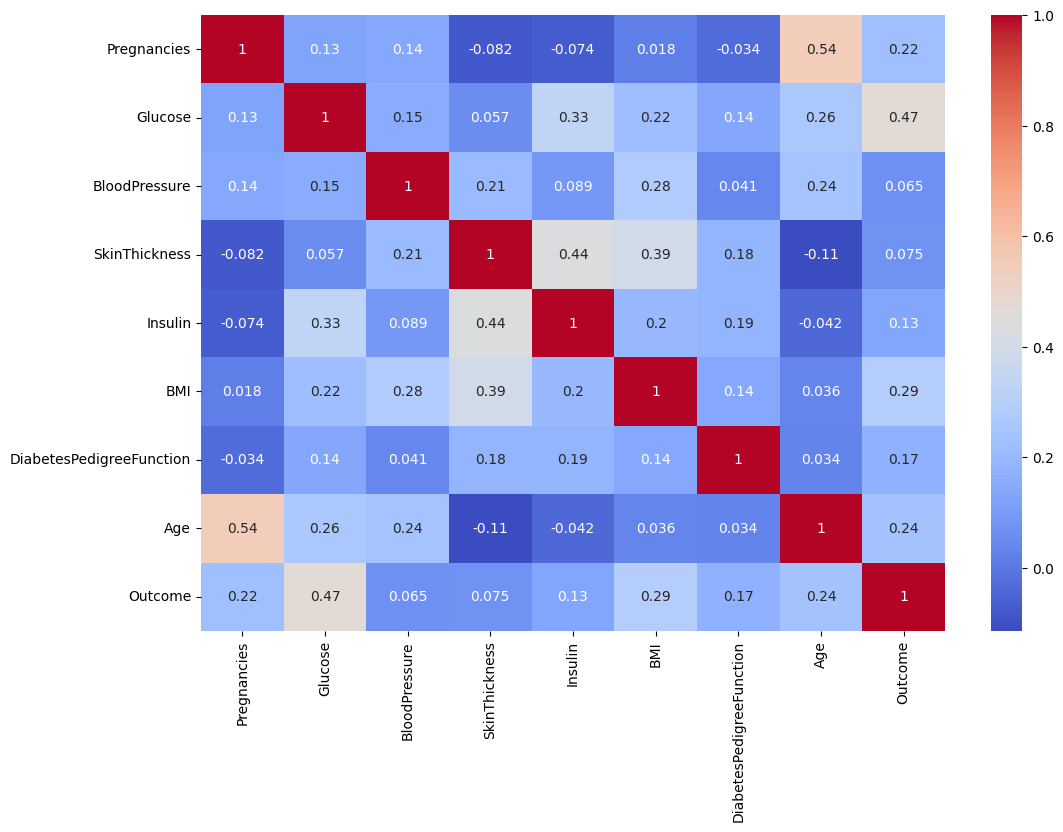

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [18]:
Y_pred = knn.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print("===== KNN =====")

print("accuracy score:",accuracy_score(Y_pred,Y_test)*100)
print("precision score:",precision_score(Y_pred,Y_test)*100)
print("recall score:",recall_score(Y_pred,Y_test)*100)
print("f1 score:",f1_score(Y_pred,Y_test)*100)
print("cm:",confusion_matrix(Y_pred,Y_test)*100)

===== KNN =====
accuracy score: 72.07792207792207
precision score: 58.18181818181818
recall score: 61.53846153846154
f1 score: 59.813084112149525
cm: [[7900 2300]
 [2000 3200]]


In [20]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train,Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [21]:
Y_predict = nb.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print("===== naive bayes =====")

print("accuracy score:",accuracy_score(Y_predict,Y_test)*100)
print("precision score:",precision_score(Y_predict,Y_test)*100)
print("recall score:",recall_score(Y_predict,Y_test)*100)
print("f1 score:",f1_score(Y_predict,Y_test)*100)
print("cm:",confusion_matrix(Y_predict,Y_test)*100)

===== naive bayes =====
accuracy score: 76.62337662337663
precision score: 70.9090909090909
recall score: 66.10169491525424
f1 score: 68.42105263157895
cm: [[7900 1600]
 [2000 3900]]


In [23]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="gini",max_depth=4)
dt.fit(X_train,Y_train)
Y_predict1 = dt.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("===== decision tree =====")


print("accuracy score",accuracy_score(Y_predict1,Y_test)*100)
print("precision_score",precision_score(Y_predict1,Y_test)*100)
print("recall_score",recall_score(Y_predict1,Y_test)*100)
print("f1_score",f1_score(Y_predict1,Y_test)*100)

===== decision tree =====
accuracy score 69.48051948051948
precision_score 69.0909090909091
recall_score 55.88235294117647
f1_score 61.78861788617886


In [25]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,Y_train)
Y_predict2 = rf.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("===== Random Forest =====")

print("accuracy score",accuracy_score(Y_predict2,Y_test)*100)
print("precision_score",precision_score(Y_predict2,Y_test)*100)
print("recall_score",recall_score(Y_predict2,Y_test)*100)
print("f1_score",f1_score(Y_predict2,Y_test)*100)

===== Random Forest =====
accuracy score 75.97402597402598
precision_score 65.45454545454545
recall_score 66.66666666666666
f1_score 66.05504587155964
